In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

## TESTE T

Uma empresa de comércio eletrônico está interessada em saber se uma nova página de destino (landing page) leva a uma taxa de conversão significativamente maior do que a página antiga.

- Hipótese Nula (H0) = Taxa Página Nova <= Taxa Página Antiga
- Hipótese Alternativa (Ha) = Taxa Página Nova > Taxa Página Antiga

In [2]:
taxa_conversao_nova = np.array([0.08, 0.09, 0.07, 0.1, 0.11, 0.09, 0.08, 0.1, 0.12, 0.1,
                                0.09, 0.08, 0.09, 0.11, 0.1, 0.08, 0.09, 0.08, 0.1, 0.11, 0.07,0.07,0.07,0.08])

taxa_conversao_antiga = np.array([0.07, 0.09, 0.08, 0.09, 0.10, 0.07, 0.08, 0.09, 0.08, 0.07,
                                  0.09, 0.08, 0.10, 0.09, 0.07, 0.09, 0.06, 0.09, 0.07, 0.06, 0.06,0.06,0.06,0.07])

O Python faz todos os cálculos de média e desvio padrão automaticamente, portanto, não é necessário calcular

In [3]:
# Realizando o Teste T de Student
t_stastistic, p_value = stats.ttest_ind(taxa_conversao_nova, taxa_conversao_antiga)

In [4]:
# Printando os resultados
print("Estatistica de teste (t-statistic):", t_stastistic)
print("P-Value:", p_value)

# Comparando o p_value com um nível de significância comum (0,05)
nivel_significancia = 0.05
if p_value < nivel_significancia:
    print("\nRejeitar a Hipótese Nula: a nova página tem uma taxa de conversão significativamente maior.")
else:
    print("\nNão há motivo para rejeitar a Hipótese Nula: a nova página de destino não tem uma taxa de conversão significativamente maior.")


Estatistica de teste (t-statistic): 3.0270374865616985
P-Value: 0.00403730766024186

Rejeitar a Hipótese Nula: a nova página tem uma taxa de conversão significativamente maior.


Gráfico de Densidade de Probabilidade

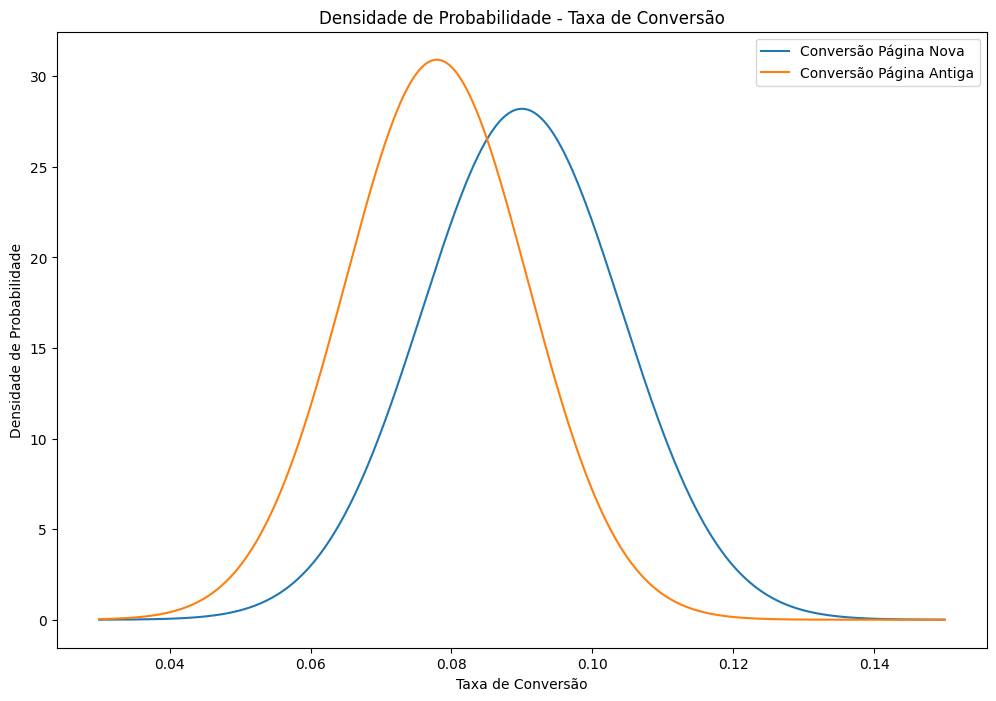

In [5]:
# Calculando a média e desvio padrão
media_nova = np.mean(taxa_conversao_nova)
desvio_padrao_nova = np.std(taxa_conversao_nova)
media_antiga = np.mean(taxa_conversao_antiga)
desvio_padrao_antiga = np.std(taxa_conversao_antiga)

# Criando um intervalo de valores para plotagem -> Evitar infinitos
eixo_x = np.linspace(0.03, 0.15, 1000) # 1: Começo, 2: Fim, 3: Quantidade de Valores

plt.figure(figsize = (12, 8))

# Linha 01 - Página Nova
plt.plot(
    eixo_x,
    norm.pdf(eixo_x, media_nova, desvio_padrao_nova), # Eixo Y: Calcula a Densidade de Probabilidade
    label = 'Conversão Página Nova',
)

# Linha 02 - Página Antiga
plt.plot(
    eixo_x,
    norm.pdf(eixo_x, media_antiga, desvio_padrao_antiga),
    label = 'Conversão Página Antiga'
)

# PERSONALIZANDO
plt.xlabel('Taxa de Conversão')
plt.ylabel('Densidade de Probabilidade')
plt.title('Densidade de Probabilidade - Taxa de Conversão')
plt.legend()
plt.show()

A partir do gráfico, notamos que a Landing Page antiga a maior parte dos valores se encontra entre 6% a 8%, enquanto na nova a maior parte se concentra entre 8% e 10%

Plotando o gráfico com a área crítica

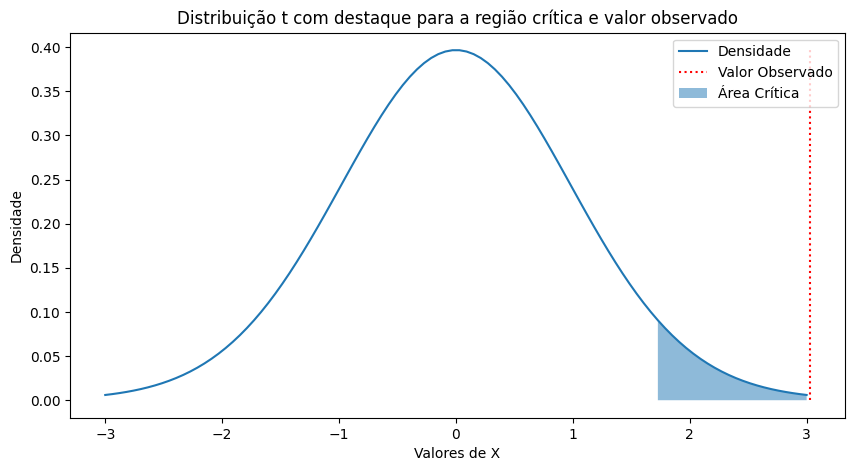

In [13]:
fig, ax = plt.subplots(figsize = (10, 5))

# Parâmetros de Densidade da Hipótese Nula (H0)
mu = 0 # Média Distribuição T sob a H0, sempre 0
varience = 1 # Variância da Distribuição T sob H0, sempre 1
sigma = varience**.5 # Desvio Padrão da Distribuição T. Desvio Padrão é a raiz quadrada da Variância

# Valores X e Y
x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 100) # Começo, fim, quantidade de números
y = stats.t.pdf(x, len(taxa_conversao_nova) + len(taxa_conversao_antiga) - 2)
# x = lista de valores da densidade de distribuição
# funções len() correspondem aos graus de liberdade

# Limites da Região Crítica
low = stats.t.ppf(.95, len(taxa_conversao_nova) + len(taxa_conversao_antiga) - 2) # Calcula o percentil 95 da distribuição
high = np.inf

# Plotando a Densidade
ax.plot(
    x,
    y,
    label = 'Densidade'
)

# Marcação do valor observado da estatística do teste
ax.vlines(
    x = [t_stastistic],
    ymin = 0,
    ymax = y.max(),
    colors = 'r',
    linestyles = 'dotted',
    label = 'Valor Observado'
)

# Preenchendo a Área Crítica
plt.fill_between(
    x,
    y,
    where = (low < x) & (x < high),
    alpha = .5,
    label = 'Área Crítica'
)

# Personalização final
plt.legend()
plt.xlabel('Valores de X')
plt.ylabel('Densidade')
plt.title('Distribuição t com destaque para a região crítica e valor observado')
plt.show()


Observamos que o valor de p-value está bem no final da área crítica, portanto, podemos rejeitar a Hipótese Nula